# ESIM induction-heating benchmark -- verified results validation

Effective Surface Impedance (ESIM) for induction-heating workpieces: a nonlinear
1D cell problem gives an H-dependent surface impedance Z_s(|H_t|), consumed by
the PEEC-BEM / FEM-Kelvin solvers. This is a **conservative validation** of the
verified, committed-JSON-backed results; the full benchmark corpus (the 108-run
sweep JSON that the golden test test_igte_dense_sweep_golden locks, the Karl
iteration histories, the IGTE-2026 digest figure scripts) is **kept** at
`validation_test/ih_esim_benchmark/`; this notebook embeds the public
result view without duplicating the validation JSON.

The figures below are the committed corpus results (the plot scripts themselves
use a LAB-private styling helper and are not re-run here); the Bessel
cross-check is reproduced live.

Phase A of the ESIM publication roadmap; VERIFIED source for the IGTE Symposium
2026 digest.

## 1. Bessel cross-check (reproduced live)

The ESIM finite-slab cell solver vs the closed-form Bessel I0/I1 surface impedance of a cylindrical conductor -- validation tier i.

*(source: `analytical_bessel_baseline.py`)*

In [1]:
"""Linear-mu cylinder analytical baseline for ESIM cell verification.

For a constant-mu conductor (cylinder of radius R, conductivity sigma,
permeability mu_0 * mu_r), Maxwell's equations admit a closed-form
surface impedance solution involving modified Bessel functions:

    Z_s(linear) = rho * gamma * I_1(gamma R) / I_0(gamma R)

where rho = 1/sigma and gamma = (1 + j) / delta with skin depth
delta = sqrt(2 / (omega mu_0 mu_r sigma)).

This script:

1. Computes the analytical Z_s for a fixed (R, sigma, mu_r) at a sweep
   of frequencies.
2. Runs the radia ESIMFiniteSlabSolver in cylinder mode at the same
   inputs (no BH curve — pure linear-mu mode) and compares Z_s.
3. Reports relative error on |Z_s|, Re(Z_s), Im(Z_s).

A passing baseline is < 0.1 % relative error on |Z_s| across the
frequency sweep, which proves the radia cell solver's discretisation
(uniform mesh, cell-centred fluxes, L'Hopital BC at r=0) is correctly
implemented.

This is a regression-quality check, not a research demo.  For
nonlinear ESIM validation, use benchmark.py.
"""

from __future__ import annotations

import math
import sys
from pathlib import Path

import numpy as np
from scipy.special import iv as bessel_iv

CWD = Path.cwd().resolve()
REPO = next(path for path in (CWD, *CWD.parents) if (path / 'src' / 'radia').is_dir())
VALIDATION_DIR = REPO / 'validation_test' / 'ih_esim_benchmark'
sys.path.insert(0, str(REPO / "src" / "radia"))
from esim_cell_problem import ESIMFiniteSlabSolver  # noqa: E402

MU_0 = 4e-7 * math.pi


def analytical_Zs_cylinder(R, sigma, mu_r, frequency):
    """Closed-form linear-mu cylinder surface impedance.

    Z_s = rho * gamma * I_1(gamma R) / I_0(gamma R)
    where rho = 1/sigma, gamma = (1 + j) / delta,
          delta = sqrt(2 / (omega mu_0 mu_r sigma)).
    """
    omega = 2 * math.pi * frequency
    rho = 1.0 / sigma
    delta = math.sqrt(2.0 / (omega * MU_0 * mu_r * sigma))
    gamma = complex(1.0, 1.0) / delta
    arg = gamma * R
    z = rho * gamma * bessel_iv(1, arg) / bessel_iv(0, arg)
    return complex(z), delta


def radia_Zs_cylinder(R, sigma, mu_r, frequency, n_nodes=2000):
    """Radia ESIMFiniteSlabSolver Z_s, cylinder mode, linear mu.

    Bypasses BH curve by passing mu_r (constant relative permeability).
    """
    esim = ESIMFiniteSlabSolver(
        half_thickness=R,
        bh_curve=None,
        sigma=sigma,
        frequency=frequency,
        mu_r=mu_r,
        n_nodes=n_nodes,
        geometry='cylinder',
    )
    res = esim.solve(H0=1.0)
    return complex(res['Z'])


def sweep():
    R = 5.0e-3          # workpiece radius [m]
    sigma = 2.0e6       # [S/m]
    mu_r = 100.0        # constant permeability
    freqs = [1.0e3, 1.0e4, 5.0e4, 1.0e5, 5.0e5, 1.0e6]

    print(f"Linear-mu cylinder cross-check")
    print(f"  R = {R*1e3:.1f} mm, sigma = {sigma:.2e} S/m, mu_r = {mu_r}")
    print()
    print(f"{'freq[Hz]':>10s}  {'delta[mm]':>9s}  {'xi':>6s}  "
          f"{'Re_anal':>11s}  {'Re_radia':>11s}  {'relErr':>9s}    "
          f"{'Im_anal':>11s}  {'Im_radia':>11s}  {'relErr':>9s}")
    print("-" * 130)

    max_rel = 0.0
    for f in freqs:
        Z_anal, delta = analytical_Zs_cylinder(R, sigma, mu_r, f)
        Z_radia = radia_Zs_cylinder(R, sigma, mu_r, f)
        xi = R / delta
        rel_re = abs(Z_radia.real - Z_anal.real) / max(abs(Z_anal.real), 1e-30)
        rel_im = abs(Z_radia.imag - Z_anal.imag) / max(abs(Z_anal.imag), 1e-30)
        rel_abs = abs(abs(Z_radia) - abs(Z_anal)) / max(abs(Z_anal), 1e-30)
        max_rel = max(max_rel, rel_abs)
        print(f"{f:>10.2e}  {delta*1e3:>9.4f}  {xi:>6.2f}  "
              f"{Z_anal.real:>11.4e}  {Z_radia.real:>11.4e}  {rel_re:>9.2e}    "
              f"{Z_anal.imag:>11.4e}  {Z_radia.imag:>11.4e}  {rel_im:>9.2e}")
    print()
    print(f"Max |Z_s| relative error across sweep: {max_rel:.3e}")
    print(f"Pass criterion (< 5e-3): {'PASS' if max_rel < 5e-3 else 'FAIL'}")
    return max_rel

sweep()


Linear-mu cylinder cross-check
  R = 5.0 mm, sigma = 2.00e+06 S/m, mu_r = 100.0

  freq[Hz]  delta[mm]      xi      Re_anal     Re_radia     relErr        Im_anal     Im_radia     relErr
----------------------------------------------------------------------------------------------------------------------------------
  1.00e+03     1.1254    4.44   3.9280e-04   3.9280e-04   1.39e-06     4.4609e-04   4.4609e-04   1.49e-06
  1.00e+04     0.3559   14.05   1.3545e-03   1.3545e-03   1.28e-05     1.4054e-03   1.4054e-03   1.32e-05
  5.00e+04     0.1592   31.42   3.0914e-03   3.0912e-03   6.27e-05     3.1418e-03   3.1416e-03   6.37e-05
  1.00e+05     0.1125   44.43   4.3927e-03   4.3922e-03   1.25e-04     4.4430e-03   4.4425e-03   1.26e-04
  5.00e+05     0.0503   99.35   9.8845e-03   9.8784e-03   6.20e-04     9.9347e-03   9.9285e-03   6.23e-04
  1.00e+06     0.0356  140.50   1.4000e-02   1.3982e-02   1.24e-03     1.4050e-02   1.4032e-02   1.24e-03

Max |Z_s| relative error across sweep: 1.239e

0.0012392419817836206

## 2. IGTE-2026 digest figure (committed)

Per-element-vs-scalar P_wp gap heatmap across the (I, f) grid, from the committed `sweep_data_dense/sweep_results.json` (golden-locked). The gap reaches tens of percent at high current / low frequency where the field is most nonlinear -- the headline finding of the digest.

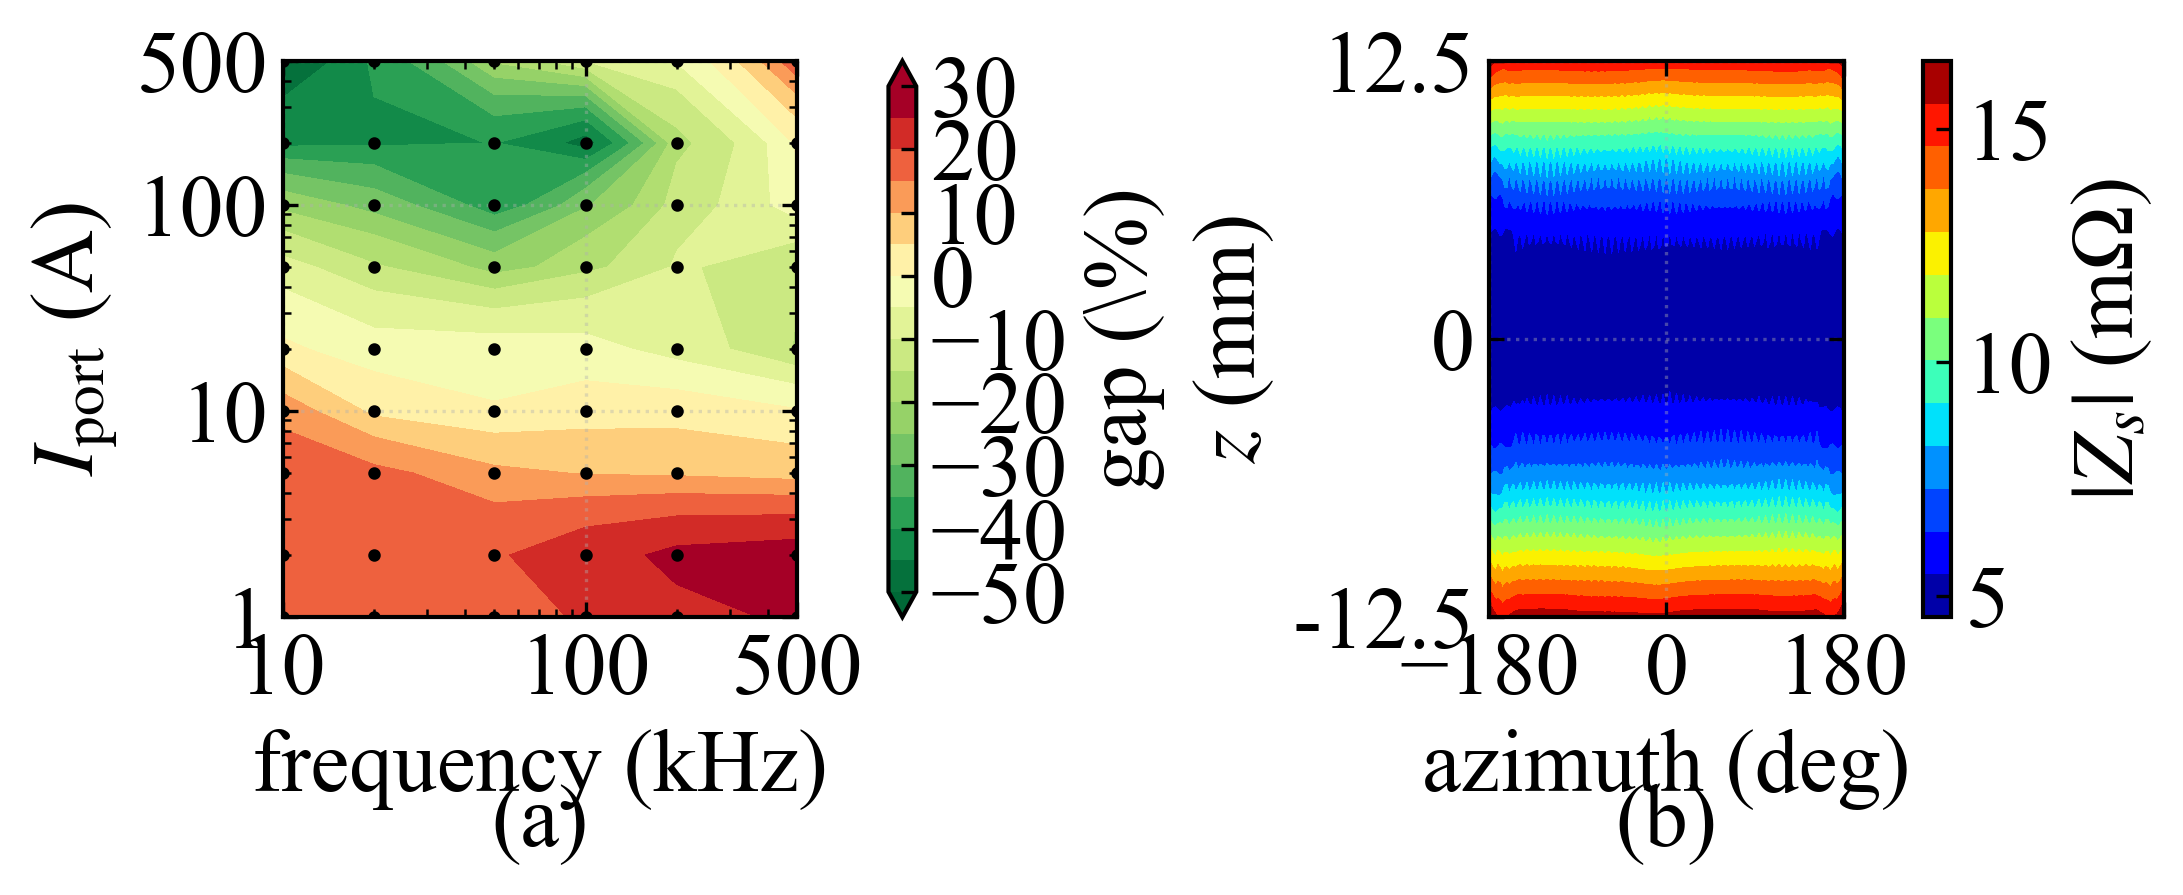

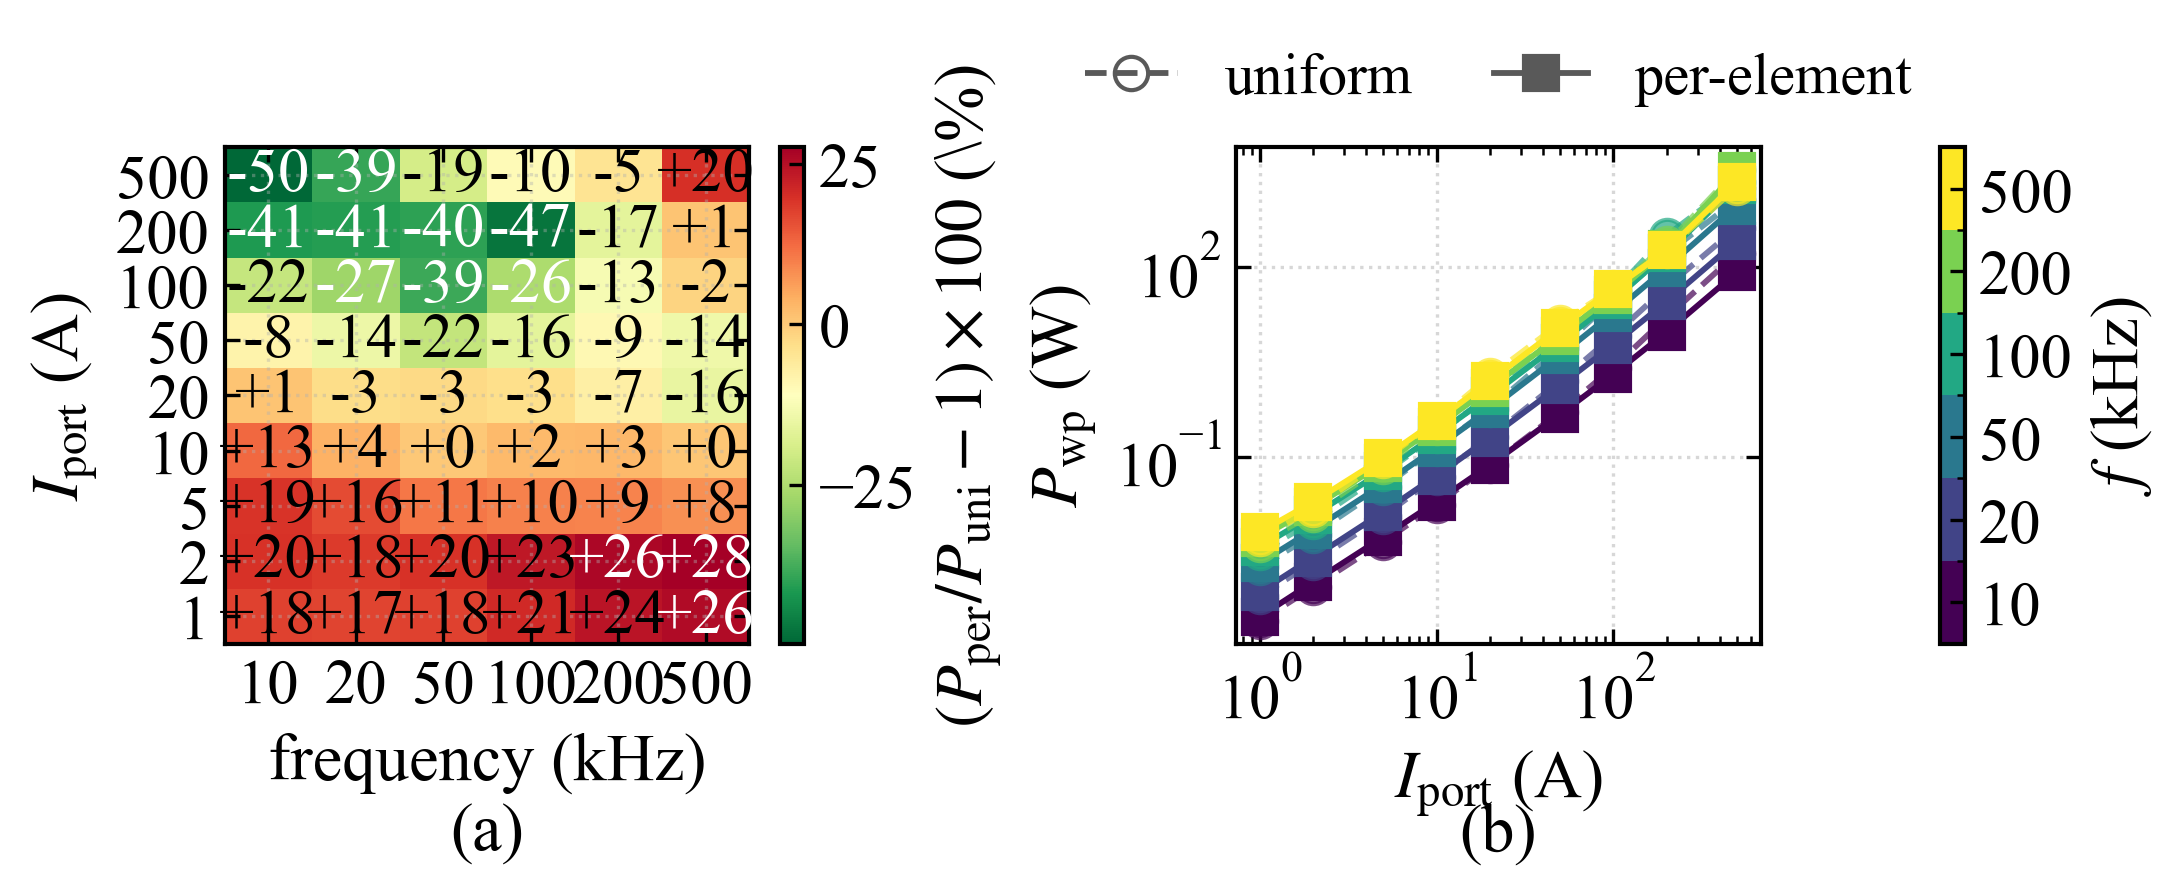

In [2]:
from IPython.display import Image, display
display(Image(filename=str(VALIDATION_DIR / "sweep_heatmap_digest.png")))
display(Image(filename=str(VALIDATION_DIR / "sweep_heatmap.png")))


## 3. Nonlinear Z_s envelope, per-DOF map, Karl convergence (committed)

The nonlinear |Z_s| envelope across |H_t| in [1, 1e5] A/m (low-H Bessel, high-H saturated thin-skin); the per-DOF Re/Im Z_s + |H_t| hotspot map (digest Fig.2); and the Karl fixed-point convergence history.

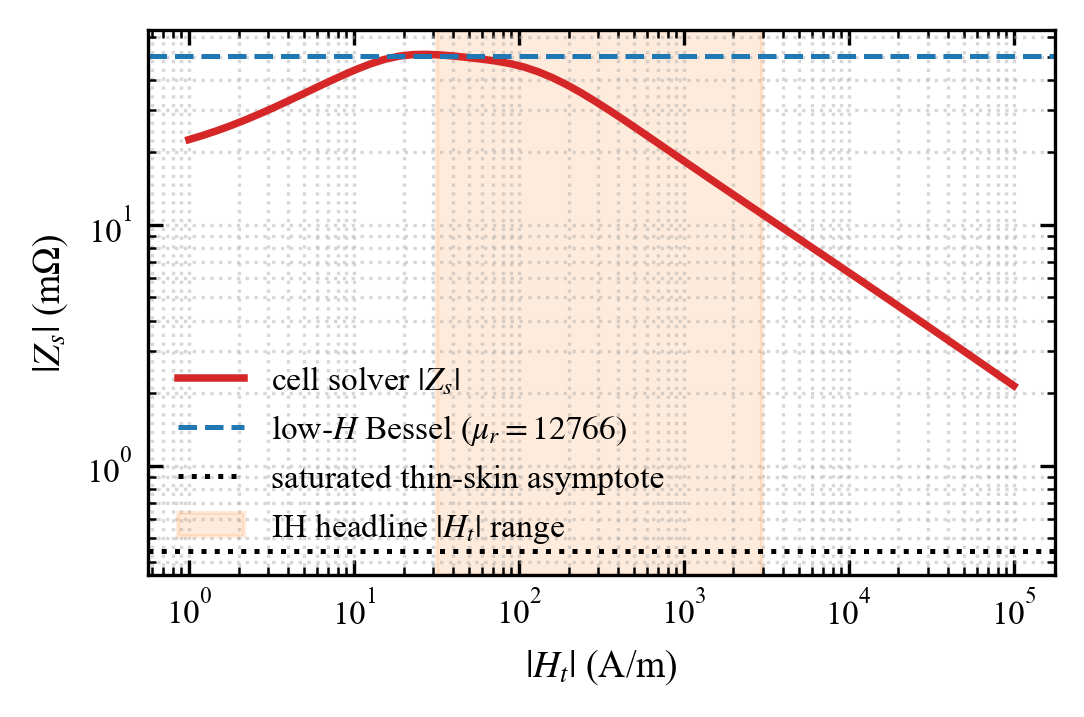

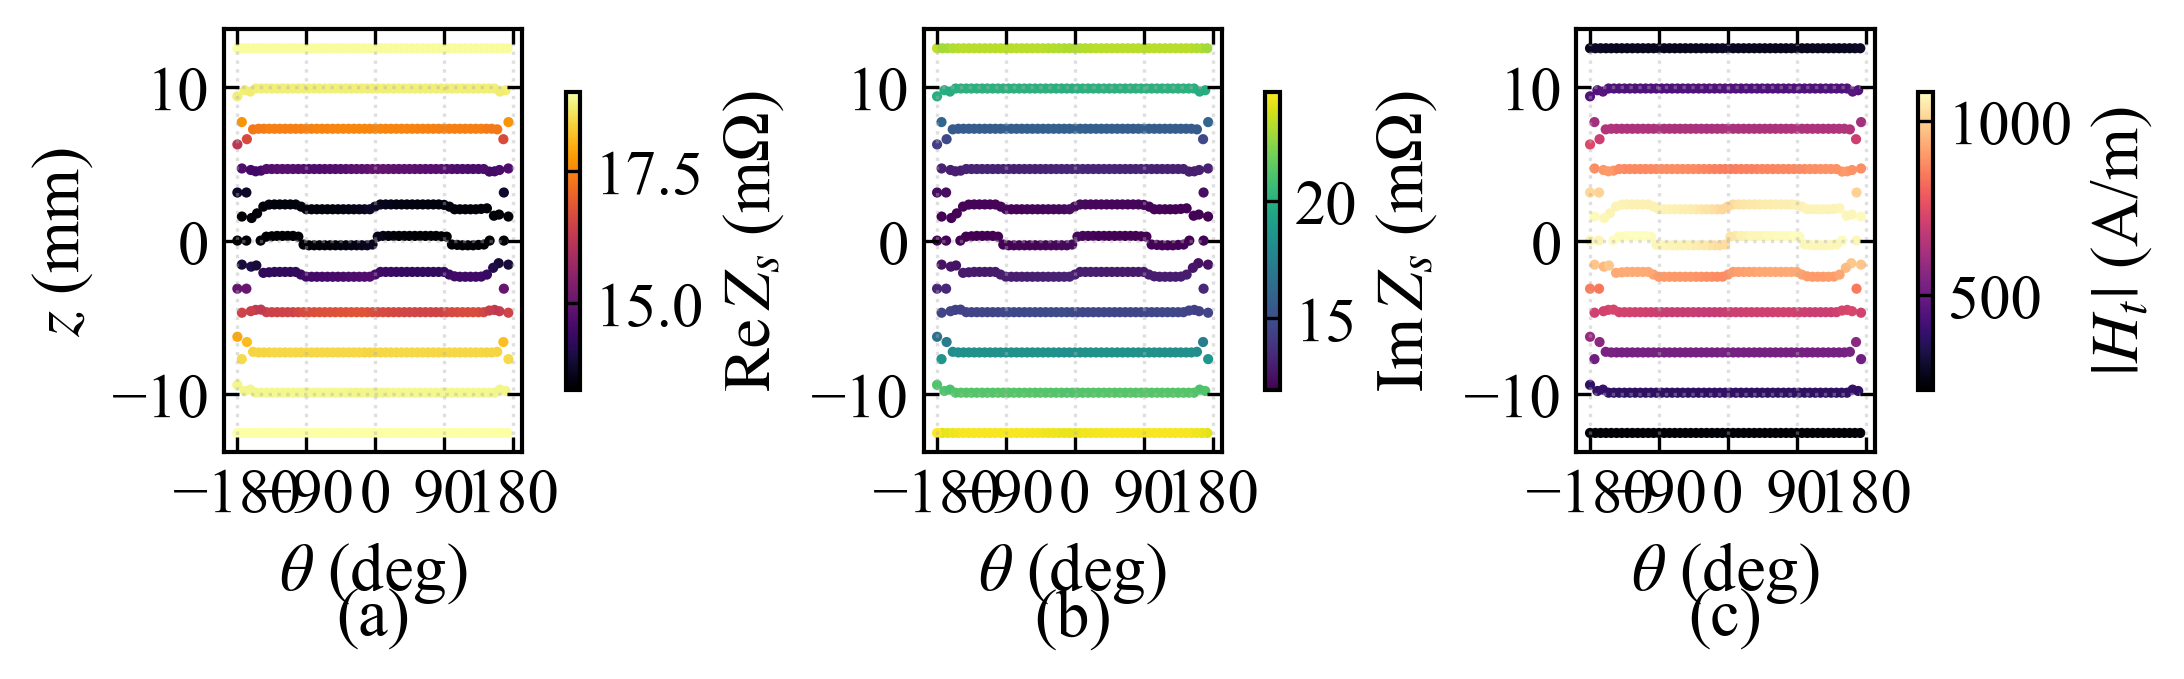

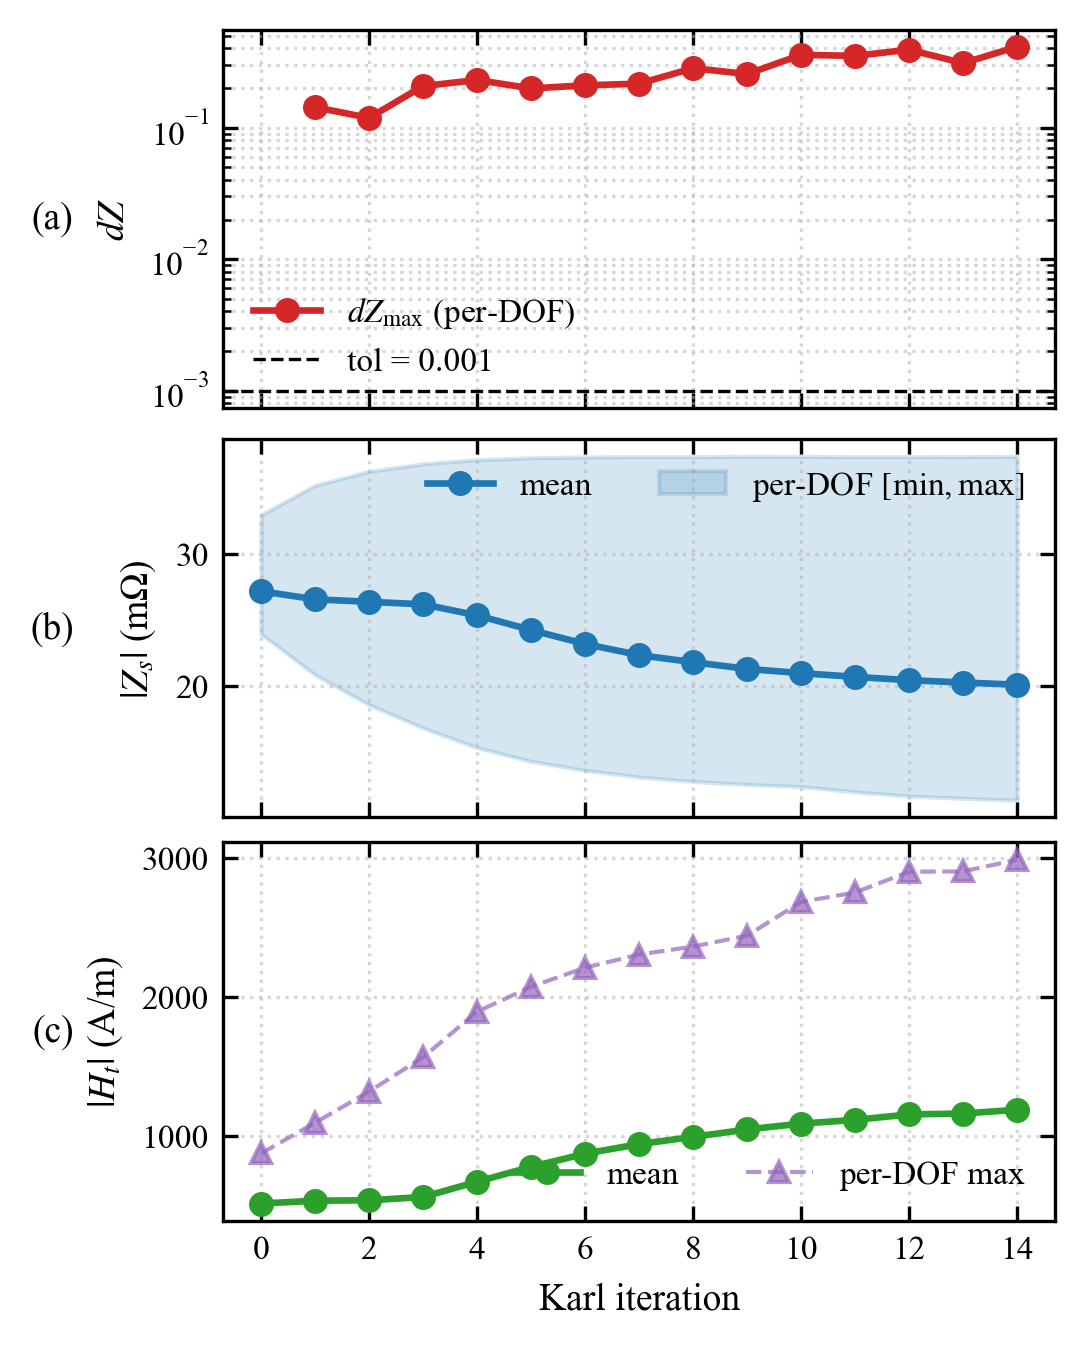

In [3]:
from IPython.display import Image, display
display(Image(filename=str(VALIDATION_DIR / "cell_envelope.png")))
display(Image(filename=str(VALIDATION_DIR / "Zs_per_dof_map.png")))
display(Image(filename=str(VALIDATION_DIR / "karl_history_per_panel.png")))
